# Strategy Comparison Backtest

Compares HMM and MSVAR against three benchmarks over the 2018-2025 test period:
- 60/40 equity-bond portfolio
- Equal-weight equity-bond-gold portfolio
- Buy-and-hold equity portfolio

Requires pre-computed target weights from notebooks 03 and 04.

## Cost and Tax Treatment

Transaction costs: 10 bps applied to traded notional (sum of absolute weight changes).
A 1-month signal lag is applied for model strategies to prevent look-ahead bias.
Tax sensitivity is reported separately as a scenario analysis.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, os

sys.path.insert(0, os.path.abspath(".."))

from src.constants import ASSET_COLS
from src.data_loader import load_asset_data, load_target_weights, validate_target_weights
from src.benchmarks import (build_constant_weights, build_equal_weight_benchmark,
                              build_sixty_forty_benchmark, build_equity_only_benchmark)
from src.backtest import backtest_with_transaction_costs, apply_asset_level_tax_sensitivity
from src.metrics import (annualized_return, annualized_volatility, sharpe_ratio,
                          sortino_ratio, max_drawdown, information_ratio,
                          summarize_performance)

DATA_DIR           = Path("../data")
OUTPUT_TABLES_DIR  = Path("../outputs/tables")
OUTPUT_FIGURES_DIR = Path("../outputs/figures")

OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TRANSACTION_COST_BPS = 10

MODEL_SIGNAL_START_DATES = {
    "HMM":   pd.Timestamp("2018-10-31"),
    "MSVAR": pd.Timestamp("2018-11-30"),
}

ASSET_TAX_RATES = {
    "No Tax": {"index_fund": 0.00, "treasury_fund": 0.00, "gold_fund": 0.00},
    "Long-Term Capital Gain Sensitivity": {"index_fund": 0.15, "treasury_fund": 0.15, "gold_fund": 0.15},
    "Gold Collectibles Sensitivity":      {"index_fund": 0.15, "treasury_fund": 0.15, "gold_fund": 0.28},
    "High Short-Term Sensitivity":        {"index_fund": 0.35, "treasury_fund": 0.35, "gold_fund": 0.35},
}

In [2]:
asset_returns = load_asset_data(DATA_DIR / "market_clean.csv")[ASSET_COLS].sort_index()
print(asset_returns.shape)
print(f"Asset return range: {asset_returns.index.min().date()} to {asset_returns.index.max().date()}")
asset_returns.head()

(431, 3)
Asset return range: 1990-02-28 to 2025-12-31


,index_fund,treasury_fund,gold_fund
Date,,,
1990-02-28,0.012748,-0.003267,0.017748
1990-03-31,0.027663,-0.003589,-0.051637
1990-04-30,-0.025015,-0.027230,-0.001374
1990-05-31,0.096928,0.044975,-0.013624
1990-06-30,-0.006555,0.022940,-0.003990


In [3]:
model_weight_files = {
    "HMM":   OUTPUT_TABLES_DIR / "hmm_target_weights.csv",
    "MSVAR": OUTPUT_TABLES_DIR / "msvar_target_weights.csv",
}

model_weights = {}
for model_name, path in model_weight_files.items():
    if path.exists():
        weights = load_target_weights(path)
        validate_target_weights(weights)
        model_weights[model_name] = weights
        print(f"Loaded {model_name} target weights from {path}")
        print(weights.head())
    else:
        print(f"Missing {model_name} target weights: {path}")

print(f"\nAvailable model weight files: {len(model_weights)}")

Loaded HMM target weights from ..\outputs\tables\hmm_target_weights.csv
            regime_label  index_fund  treasury_fund  gold_fund
Date                                                          
1990-02-28             0    0.304427       0.448602   0.246971
1990-03-31             0    0.304427       0.448602   0.246971
1990-04-30             0    0.304427       0.448602   0.246971
1990-05-31             0    0.304427       0.448602   0.246971
1990-06-30             0    0.304427       0.448602   0.246971
Loaded MSVAR target weights from ..\outputs\tables\msvar_target_weights.csv
            regime_label  index_fund  treasury_fund  gold_fund
Date                                                          
1990-03-31             0    0.317679       0.328343   0.353978
1990-04-30             0    0.317679       0.328343   0.353978
1990-05-31             0    0.317679       0.328343   0.353978
1990-06-30             0    0.317679       0.328343   0.353978
1990-07-31             0    0.317

In [4]:
benchmark_weights = {
    "60_40":           build_sixty_forty_benchmark(asset_returns.index),
    "Equal_Weight":    build_equal_weight_benchmark(asset_returns.index),
    "Buy_Hold_Equity": build_equity_only_benchmark(asset_returns.index),
}
list(benchmark_weights.keys())

['60_40', 'Equal_Weight', 'Buy_Hold_Equity']

In [5]:
model_weights_test = {}

for model_name, weights in model_weights.items():
    signal_start = MODEL_SIGNAL_START_DATES[model_name]
    model_weights_test[model_name] = weights.loc[weights.index >= signal_start].copy()
    print(
        f"{model_name} signal test period starts at {signal_start.date()} "
        f"with {len(model_weights_test[model_name])} signal observations."
    )

all_target_weights = {}
all_target_weights.update(model_weights_test)
all_target_weights.update(benchmark_weights)

cost_results_raw = {}

for strategy_name, weights in all_target_weights.items():
    is_model_strategy = strategy_name in model_weights_test

    result = backtest_with_transaction_costs(
        target_weights=weights,
        asset_returns=asset_returns,
        transaction_cost_bps=TRANSACTION_COST_BPS,
        apply_signal_lag=is_model_strategy,
        include_initial_trade_cost=False,
    )

    cost_results_raw[strategy_name] = result

# Align all strategies to the same realized-return comparison period
common_result_index = None
for result in cost_results_raw.values():
    if common_result_index is None:
        common_result_index = result.index
    else:
        common_result_index = common_result_index.intersection(result.index)

cost_results = {
    strategy_name: result.loc[common_result_index].copy()
    for strategy_name, result in cost_results_raw.items()
}

for strategy_name, result in cost_results.items():
    first_date = result.index[0]
    result.loc[first_date, "trade_notional"] = 0.0
    result.loc[first_date, "one_way_turnover"] = 0.0
    result.loc[first_date, "transaction_cost"] = 0.0
    result.loc[first_date, "net_return_after_costs"] = result.loc[first_date, "gross_return"]

for strategy_name, result in cost_results.items():
    output_path = OUTPUT_TABLES_DIR / f"{strategy_name.lower()}_monthly_returns_with_costs.csv"
    result.to_csv(output_path)
    print(f"Saved {strategy_name}: {result.index.min().date()} to {result.index.max().date()}, {len(result)} months")

test_period_info = pd.DataFrame({
    "Strategy": list(cost_results.keys()),
    "Signal Start Date": [
        MODEL_SIGNAL_START_DATES.get(s, pd.NaT) for s in cost_results.keys()
    ],
    "Realized Return Start Date": [
        cost_results[s].index.min() for s in cost_results.keys()
    ],
    "Realized Return End Date": [
        cost_results[s].index.max() for s in cost_results.keys()
    ],
    "Number of Return Observations": [
        len(cost_results[s]) for s in cost_results.keys()
    ],
})
test_period_info.to_csv(OUTPUT_TABLES_DIR / "test_period_info.csv", index=False)
test_period_info

HMM signal test period starts at 2018-10-31 with 87 signal observations.
MSVAR signal test period starts at 2018-11-30 with 86 signal observations.
Saved HMM: 2018-12-31 to 2025-12-31, 85 months
Saved MSVAR: 2018-12-31 to 2025-12-31, 85 months
Saved 60_40: 2018-12-31 to 2025-12-31, 85 months
Saved Equal_Weight: 2018-12-31 to 2025-12-31, 85 months
Saved Buy_Hold_Equity: 2018-12-31 to 2025-12-31, 85 months


,Strategy,Signal Start Date,Realized Return Start Date,Realized Return End Date,Number of Return Observations
0,HMM,2018-10-31,2018-12-31,2025-12-31,85
1,MSVAR,2018-11-30,2018-12-31,2025-12-31,85
2,60_40,NaT,2018-12-31,2025-12-31,85
3,Equal_Weight,NaT,2018-12-31,2025-12-31,85
4,Buy_Hold_Equity,NaT,2018-12-31,2025-12-31,85


## Risk-free Rate for Risk-adjusted Metrics

Sharpe and Sortino ratios are computed using the average effective federal funds rate over the common test period. This keeps the notebook outputs consistent with the final report.

In [6]:
macro_level_data = pd.read_csv(DATA_DIR / "macro_data.csv")

date_col = "Date" if "Date" in macro_level_data.columns else macro_level_data.columns[0]

macro_level_data[date_col] = pd.to_datetime(macro_level_data[date_col])
macro_level_data = macro_level_data.set_index(date_col).sort_index()

risk_free_annual_series = macro_level_data["fed_funds_rate"] / 100.0

risk_free_common_index = risk_free_annual_series.index.intersection(common_result_index)
risk_free_common = risk_free_annual_series.loc[risk_free_common_index]

ANNUAL_RISK_FREE_RATE = float(risk_free_common.mean())

print(f"Average annual risk-free rate over test period: {ANNUAL_RISK_FREE_RATE:.4%}")

Average annual risk-free rate over test period: 2.6635%


## Performance Metrics

Primary comparison uses net returns after transaction costs.

In [7]:
benchmark_reference_net = cost_results["60_40"]["net_return_after_costs"]

net_strategy_comparison = pd.DataFrame({
    strategy_name: summarize_performance(
        result["net_return_after_costs"],
        benchmark_returns=None if strategy_name == "60_40" else benchmark_reference_net,
        risk_free_rate=ANNUAL_RISK_FREE_RATE,
    )
    for strategy_name, result in cost_results.items()
})

metric_order = [
    "Annualized Return",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Sortino Ratio",
    "Max Drawdown",
    "VaR 95% (monthly)",
    "CVaR 95% (monthly)",
    "Information Ratio vs 60/40",
]

net_strategy_comparison = net_strategy_comparison.reindex(
    [m for m in metric_order if m in net_strategy_comparison.index]
)

net_strategy_comparison.to_csv(OUTPUT_TABLES_DIR / "net_after_cost_strategy_comparison.csv")
net_strategy_comparison

,HMM,MSVAR,60_40,Equal_Weight,Buy_Hold_Equity
Annualized Return,0.104933,0.120785,0.101011,0.121807,0.154681
Annualized Volatility,0.101296,0.095278,0.126502,0.096629,0.169815
Sharpe Ratio,0.776086,0.969804,0.615777,0.967087,0.779533
Sortino Ratio,1.250101,1.563318,1.037141,1.589712,1.189085
Max Drawdown,-0.219934,-0.195660,-0.257392,-0.196336,-0.239596
VaR 95% (monthly),0.033395,0.030764,0.048479,0.030855,0.082662
CVaR 95% (monthly),0.052056,0.047454,0.067519,0.048448,0.095348
Information Ratio vs 60/40,0.012543,0.226197,NaN,0.260099,0.683755


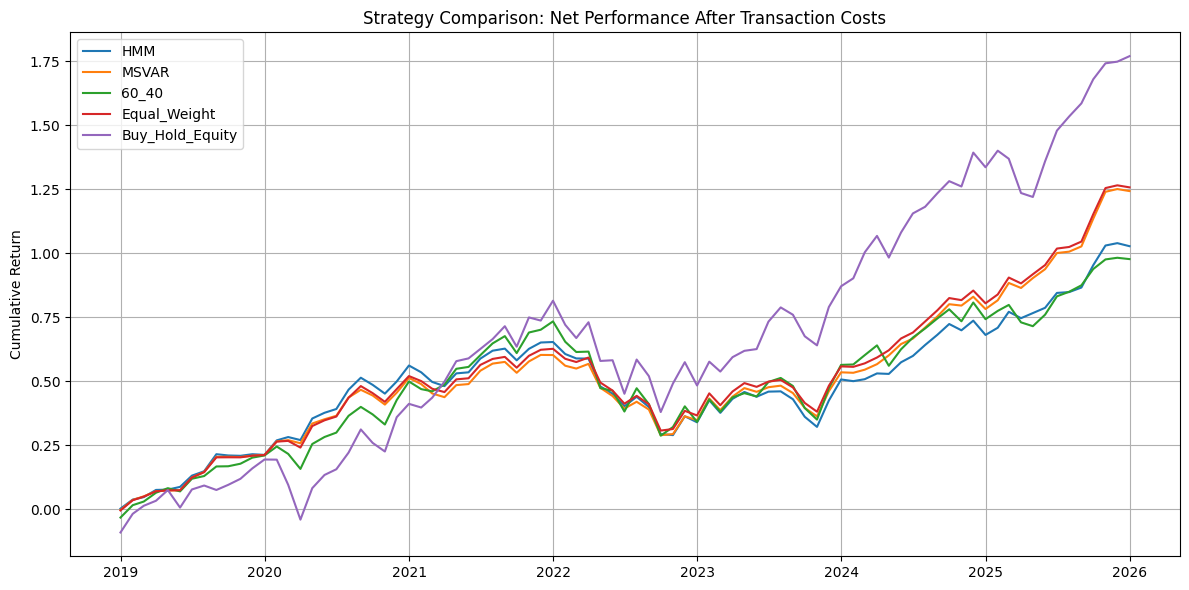

In [8]:
net_return_series = pd.DataFrame({
    strategy_name: result["net_return_after_costs"]
    for strategy_name, result in cost_results.items()
})

net_cumulative_returns = (1 + net_return_series).cumprod() - 1
net_cumulative_returns.to_csv(OUTPUT_TABLES_DIR / "net_after_cost_cumulative_returns.csv")

plt.figure(figsize=(12, 6))
for col in net_cumulative_returns.columns:
    plt.plot(net_cumulative_returns.index, net_cumulative_returns[col], label=col)
plt.title("Strategy Comparison: Net Performance After Transaction Costs")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / "net_after_cost_strategy_comparison.png", dpi=300)
plt.show()

In [9]:
ranking_metrics = [
    "Annualized Return",
    "Sharpe Ratio",
    "Sortino Ratio",
    "Max Drawdown",
    "Information Ratio vs 60/40",
]

strategy_ranking = net_strategy_comparison.loc[
    [m for m in ranking_metrics if m in net_strategy_comparison.index]
].T

strategy_ranking["Return Rank"]  = strategy_ranking["Annualized Return"].rank(ascending=False)
strategy_ranking["Sharpe Rank"]  = strategy_ranking["Sharpe Ratio"].rank(ascending=False)
strategy_ranking["Sortino Rank"] = strategy_ranking["Sortino Ratio"].rank(ascending=False)
strategy_ranking["Drawdown Rank"] = strategy_ranking["Max Drawdown"].rank(ascending=False)
strategy_ranking = strategy_ranking.sort_values("Sharpe Rank")

strategy_ranking.to_csv(OUTPUT_TABLES_DIR / "net_after_cost_strategy_ranking.csv")
strategy_ranking

,Annualized Return,Sharpe Ratio,Sortino Ratio,Max Drawdown,Information Ratio vs 60/40,Return Rank,Sharpe Rank,Sortino Rank,Drawdown Rank
MSVAR,0.120785,0.969804,1.563318,-0.195660,0.226197,3.0,1.0,2.0,1.0
Equal_Weight,0.121807,0.967087,1.589712,-0.196336,0.260099,2.0,2.0,1.0,2.0
Buy_Hold_Equity,0.154681,0.779533,1.189085,-0.239596,0.683755,1.0,3.0,4.0,4.0
HMM,0.104933,0.776086,1.250101,-0.219934,0.012543,4.0,4.0,3.0,3.0
60_40,0.101011,0.615777,1.037141,-0.257392,NaN,5.0,5.0,5.0,5.0


## Subperiod Robustness Analysis

The main comparison uses the full common test period. This section checks whether the relative performance of MSVAR and HMM is stable across key market environments inside the test window.

The subperiods are defined as the pre-COVID test window, the 2020 COVID shock, the 2021–2022 inflation and rate-rise episode, and the post-2022 normalization period.

In [10]:
common_start = net_return_series.index.min()
common_end = net_return_series.index.max()

SUBPERIODS = {
    "Full_Test_Period": (common_start, common_end),
    "COVID_2020": (pd.Timestamp("2020-03-31"), pd.Timestamp("2020-12-31")),
    "Inflation_Rate_Rise_2021_2022": (pd.Timestamp("2021-01-31"), pd.Timestamp("2022-12-31")),
    "Post_2022_Normalization": (pd.Timestamp("2023-01-31"), common_end),
}

subperiod_performance_blocks = []
subperiod_cumulative_returns = {}

for period_name, (start_date, end_date) in SUBPERIODS.items():
    period_returns = net_return_series.loc[
        (net_return_series.index >= pd.Timestamp(start_date))
        & (net_return_series.index <= pd.Timestamp(end_date))
    ]

    if period_returns.empty:
        print(f"Skipping {period_name}: no observations.")
        continue

    period_benchmark = period_returns["60_40"]

    period_summary = pd.DataFrame({
        strategy_name: summarize_performance(
            period_returns[strategy_name],
            benchmark_returns=None if strategy_name == "60_40" else period_benchmark,
            risk_free_rate=ANNUAL_RISK_FREE_RATE,
        )
        for strategy_name in period_returns.columns
    })

    period_summary.insert(0, "Subperiod", period_name)
    period_summary.insert(1, "Start Date", period_returns.index.min())
    period_summary.insert(2, "End Date", period_returns.index.max())
    period_summary.insert(3, "Months", len(period_returns))
    period_summary.insert(4, "Metric", period_summary.index)

    subperiod_performance_blocks.append(period_summary.reset_index(drop=True))
    subperiod_cumulative_returns[period_name] = period_returns.add(1.0).prod() - 1.0

subperiod_performance = pd.concat(subperiod_performance_blocks, ignore_index=True)

subperiod_performance.to_csv(
    OUTPUT_TABLES_DIR / "subperiod_performance.csv",
    index=False,
)

subperiod_cumulative_returns = pd.DataFrame(subperiod_cumulative_returns).T

subperiod_cumulative_returns.to_csv(
    OUTPUT_TABLES_DIR / "subperiod_cumulative_returns.csv",
)

display(subperiod_performance)
display(subperiod_cumulative_returns)

,Subperiod,Start Date,End Date,Months,Metric,HMM,MSVAR,60_40,Equal_Weight,Buy_Hold_Equity
0,Full_Test_Period,2018-12-31,2025-12-31,85,Annualized Return,0.104933,0.120785,0.101011,0.121807,0.154681
1,Full_Test_Period,2018-12-31,2025-12-31,85,Annualized Volatility,0.101296,0.095278,0.126502,0.096629,0.169815
2,Full_Test_Period,2018-12-31,2025-12-31,85,CVaR 95% (monthly),0.052056,0.047454,0.067519,0.048448,0.095348
3,Full_Test_Period,2018-12-31,2025-12-31,85,Information Ratio vs 60/40,0.012543,0.226197,NaN,0.260099,0.683755
4,Full_Test_Period,2018-12-31,2025-12-31,85,Max Drawdown,-0.219934,-0.195660,-0.257392,-0.196336,-0.239596
5,Full_Test_Period,2018-12-31,2025-12-31,85,Sharpe Ratio,0.776086,0.969804,0.615777,0.967087,0.779533
6,Full_Test_Period,2018-12-31,2025-12-31,85,Sortino Ratio,1.250101,1.563318,1.037141,1.589712,1.189085
7,Full_Test_Period,2018-12-31,2025-12-31,85,VaR 95% (monthly),0.033395,0.030764,0.048479,0.030855,0.082662
8,COVID_2020,2020-03-31,2020-12-31,10,Annualized Return,0.266898,0.233768,0.285024,0.244279,0.355903
9,COVID_2020,2020-03-31,2020-12-31,10,Annualized Volatility,0.105559,0.100098,0.152357,0.110231,0.260400


,HMM,MSVAR,60_40,Equal_Weight,Buy_Hold_Equity
Full_Test_Period,1.027504,1.242767,0.977082,1.257287,1.769742
COVID_2020,0.217918,0.191319,0.232422,0.199770,0.288815
Inflation_Rate_Rise_2021_2022,-0.142006,-0.109046,-0.105284,-0.101121,0.050769
Post_2022_Normalization,0.513302,0.663789,0.474082,0.651813,0.866973


In [11]:
msvar_vs_hmm_rows = []

for period_name, (start_date, end_date) in SUBPERIODS.items():
    period_returns = net_return_series.loc[
        (net_return_series.index >= pd.Timestamp(start_date))
        & (net_return_series.index <= pd.Timestamp(end_date))
    ]

    if period_returns.empty:
        continue

    if "HMM" not in period_returns.columns or "MSVAR" not in period_returns.columns:
        continue

    period_benchmark = period_returns["60_40"]

    hmm_summary = summarize_performance(
        period_returns["HMM"],
        benchmark_returns=period_benchmark,
        risk_free_rate=ANNUAL_RISK_FREE_RATE,
    )

    msvar_summary = summarize_performance(
        period_returns["MSVAR"],
        benchmark_returns=period_benchmark,
        risk_free_rate=ANNUAL_RISK_FREE_RATE,
    )

    hmm_cumulative_return = period_returns["HMM"].add(1.0).prod() - 1.0
    msvar_cumulative_return = period_returns["MSVAR"].add(1.0).prod() - 1.0

    row = {
        "Subperiod": period_name,
        "Start Date": period_returns.index.min(),
        "End Date": period_returns.index.max(),
        "Months": len(period_returns),

        "HMM Cumulative Return": hmm_cumulative_return,
        "MSVAR Cumulative Return": msvar_cumulative_return,
        "MSVAR - HMM Cumulative Return": msvar_cumulative_return - hmm_cumulative_return,

        "HMM Annualized Return": hmm_summary["Annualized Return"],
        "MSVAR Annualized Return": msvar_summary["Annualized Return"],
        "MSVAR - HMM Annualized Return": msvar_summary["Annualized Return"] - hmm_summary["Annualized Return"],

        "HMM Sharpe Ratio": hmm_summary["Sharpe Ratio"],
        "MSVAR Sharpe Ratio": msvar_summary["Sharpe Ratio"],
        "MSVAR - HMM Sharpe Ratio": msvar_summary["Sharpe Ratio"] - hmm_summary["Sharpe Ratio"],

        "HMM Sortino Ratio": hmm_summary["Sortino Ratio"],
        "MSVAR Sortino Ratio": msvar_summary["Sortino Ratio"],
        "MSVAR - HMM Sortino Ratio": msvar_summary["Sortino Ratio"] - hmm_summary["Sortino Ratio"],

        "HMM Max Drawdown": hmm_summary["Max Drawdown"],
        "MSVAR Max Drawdown": msvar_summary["Max Drawdown"],
        "MSVAR - HMM Max Drawdown": msvar_summary["Max Drawdown"] - hmm_summary["Max Drawdown"],
    }

    if "Information Ratio vs 60/40" in hmm_summary.index and "Information Ratio vs 60/40" in msvar_summary.index:
        row["HMM Information Ratio vs 60/40"] = hmm_summary["Information Ratio vs 60/40"]
        row["MSVAR Information Ratio vs 60/40"] = msvar_summary["Information Ratio vs 60/40"]
        row["MSVAR - HMM Information Ratio"] = (
            msvar_summary["Information Ratio vs 60/40"]
            - hmm_summary["Information Ratio vs 60/40"]
        )

    row["MSVAR Higher Cumulative Return"] = row["MSVAR - HMM Cumulative Return"] > 0
    row["MSVAR Higher Sharpe"] = row["MSVAR - HMM Sharpe Ratio"] > 0
    row["MSVAR Lower Drawdown"] = row["MSVAR Max Drawdown"] > row["HMM Max Drawdown"]

    msvar_vs_hmm_rows.append(row)

msvar_vs_hmm_subperiod_advantage = pd.DataFrame(msvar_vs_hmm_rows)

msvar_vs_hmm_subperiod_advantage.to_csv(
    OUTPUT_TABLES_DIR / "msvar_vs_hmm_subperiod_advantage.csv",
    index=False,
)

msvar_vs_hmm_subperiod_advantage

,Subperiod,Start Date,End Date,Months,HMM Cumulative Return,MSVAR Cumulative Return,MSVAR - HMM Cumulative Return,HMM Annualized Return,MSVAR Annualized Return,MSVAR - HMM Annualized Return,...,MSVAR - HMM Sortino Ratio,HMM Max Drawdown,MSVAR Max Drawdown,MSVAR - HMM Max Drawdown,HMM Information Ratio vs 60/40,MSVAR Information Ratio vs 60/40,MSVAR - HMM Information Ratio,MSVAR Higher Cumulative Return,MSVAR Higher Sharpe,MSVAR Lower Drawdown
0,Full_Test_Period,2018-12-31,2025-12-31,85,1.027504,1.242767,0.215264,0.104933,0.120785,0.015853,...,0.313217,-0.219934,-0.195660,0.024275,0.012543,0.226197,0.213654,True,True,True
1,COVID_2020,2020-03-31,2020-12-31,10,0.217918,0.191319,-0.026600,0.266898,0.233768,-0.033130,...,-1.709706,-0.041020,-0.039357,0.001663,-0.288414,-0.677475,-0.389061,False,False,True
2,Inflation_Rate_Rise_2021_2022,2021-01-31,2022-12-31,24,-0.142006,-0.109046,0.032961,-0.073721,-0.056096,0.017624,...,0.163766,-0.219934,-0.195660,0.024275,-0.417452,-0.110754,0.306699,True,True,True
3,Post_2022_Normalization,2023-01-31,2025-12-31,36,0.513302,0.663789,0.150487,0.148088,0.184948,0.036860,...,0.906492,-0.095045,-0.080853,0.014192,0.141869,0.596879,0.455010,True,True,True


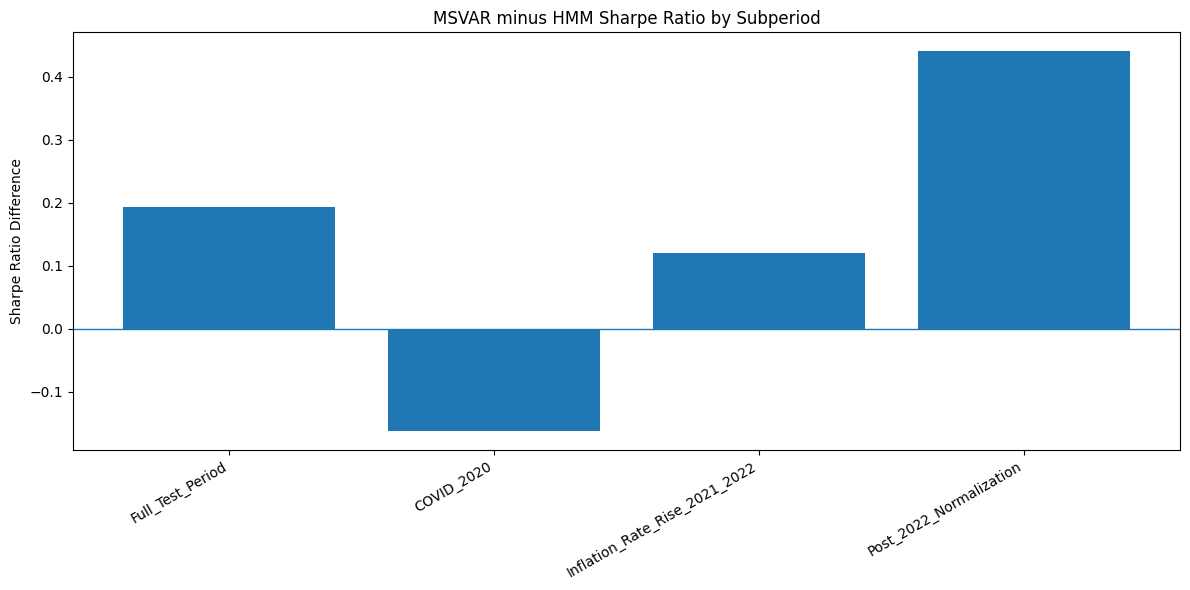

Saved figure to ..\outputs\figures\msvar_minus_hmm_sharpe_by_subperiod.png


In [12]:
plt.figure(figsize=(12, 6))

plot_data = msvar_vs_hmm_subperiod_advantage.set_index("Subperiod")

plt.bar(
    plot_data.index,
    plot_data["MSVAR - HMM Sharpe Ratio"],
)

plt.axhline(0, linewidth=1)
plt.title("MSVAR minus HMM Sharpe Ratio by Subperiod")
plt.ylabel("Sharpe Ratio Difference")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

output_path = OUTPUT_FIGURES_DIR / "msvar_minus_hmm_sharpe_by_subperiod.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to {output_path}")

## Implementation Cost Summary

In [13]:
implementation_cost_summary = pd.DataFrame({
    strategy_name: pd.Series({
        "Average Trade Notional": result["trade_notional"].mean(),
        "Average One-Way Turnover": result["one_way_turnover"].mean(),
        "Average Monthly Transaction Cost": result["transaction_cost"].mean(),
    })
    for strategy_name, result in cost_results.items()
})
implementation_cost_summary.to_csv(OUTPUT_TABLES_DIR / "implementation_cost_summary.csv")
implementation_cost_summary

,HMM,MSVAR,60_40,Equal_Weight,Buy_Hold_Equity
Average Trade Notional,0.037957,0.026531,0.020448,0.023722,0.0
Average One-Way Turnover,0.018978,0.013265,0.010224,0.011861,0.0
Average Monthly Transaction Cost,0.000038,0.000027,0.000020,0.000024,0.0


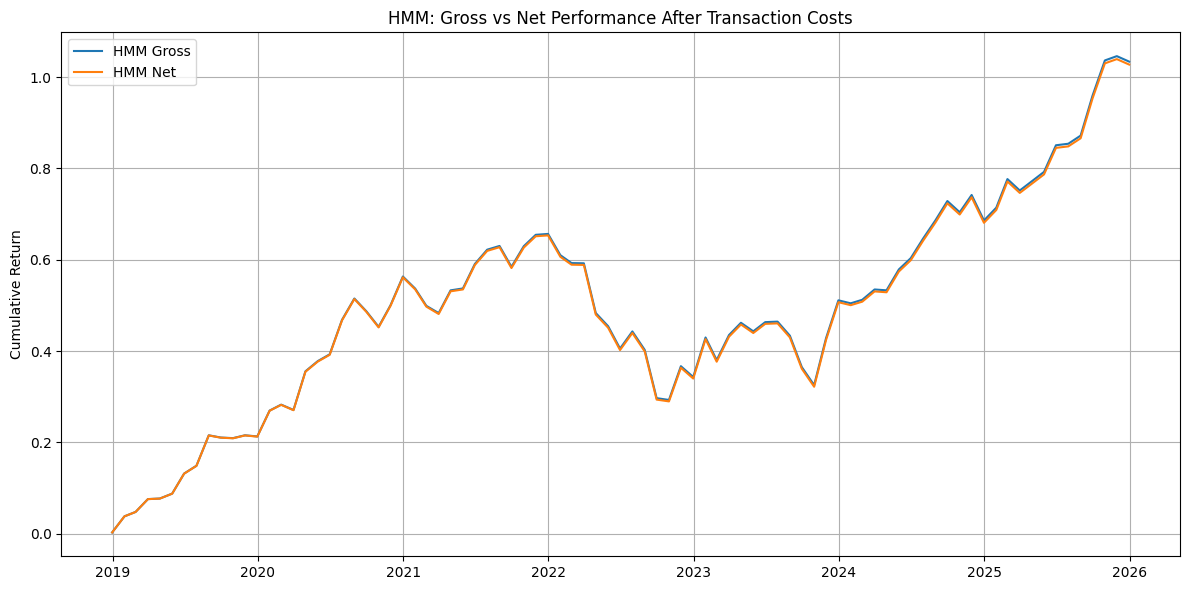

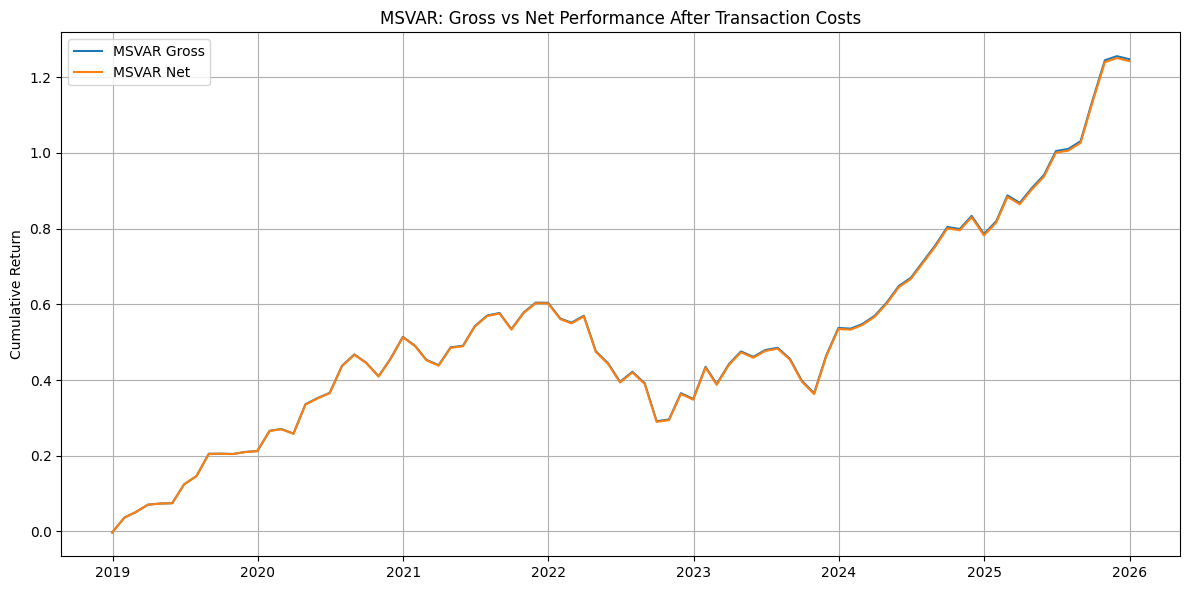

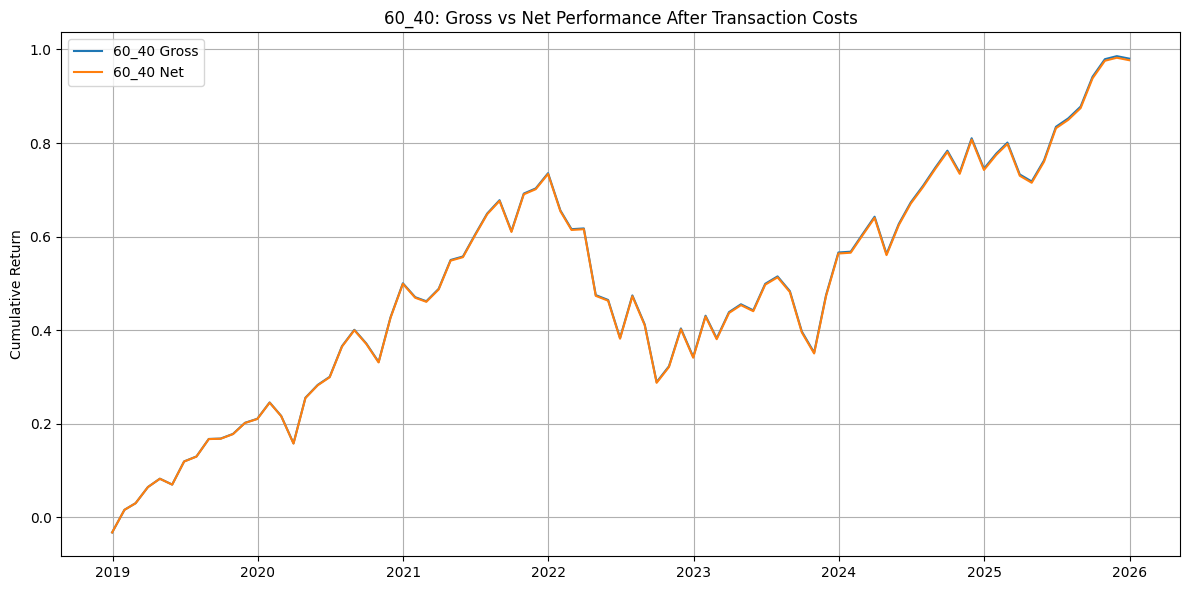

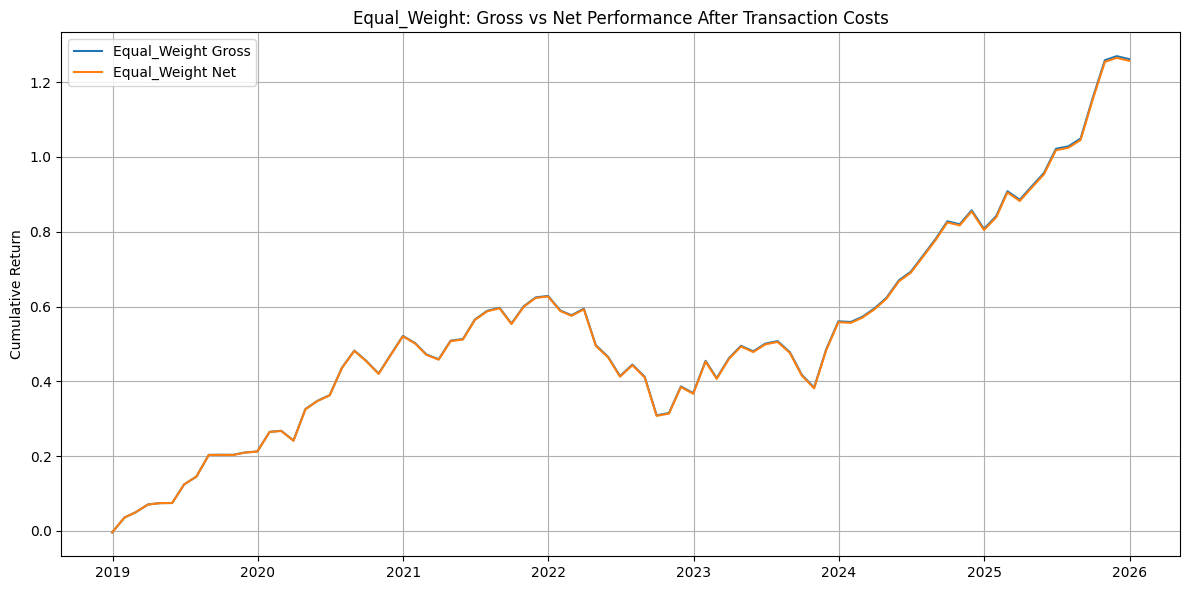

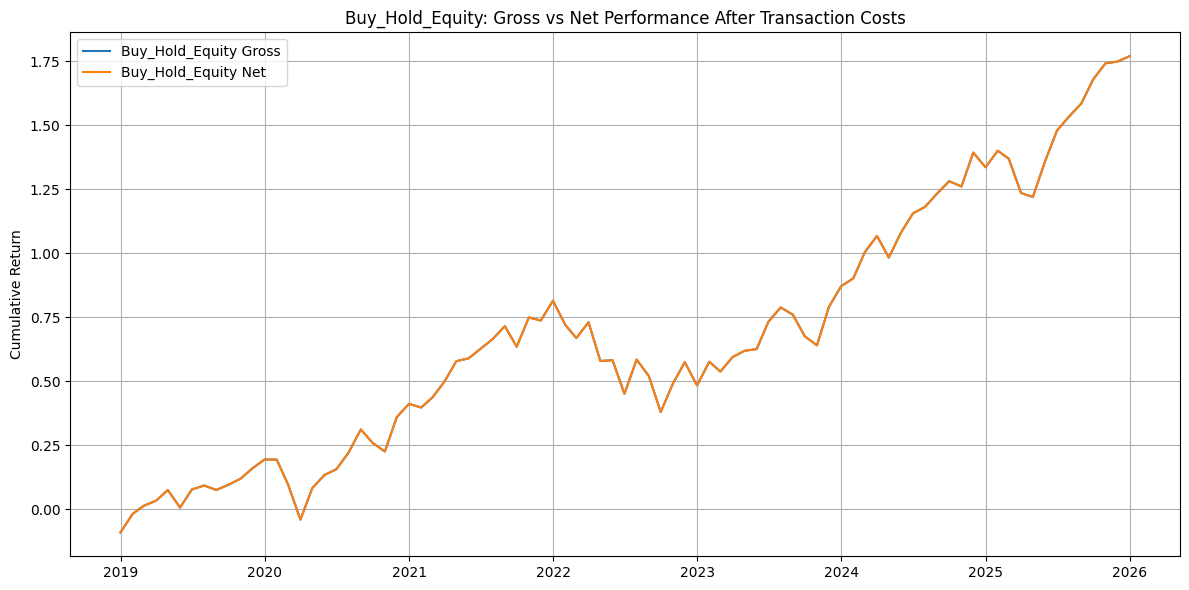

In [14]:
for strategy_name, result in cost_results.items():
    cumulative = (1 + result[["gross_return", "net_return_after_costs"]]).cumprod() - 1

    plt.figure(figsize=(12, 6))
    plt.plot(cumulative.index, cumulative["gross_return"], label=f"{strategy_name} Gross")
    plt.plot(cumulative.index, cumulative["net_return_after_costs"], label=f"{strategy_name} Net")
    plt.title(f"{strategy_name}: Gross vs Net Performance After Transaction Costs")
    plt.ylabel("Cumulative Return")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    output_path = OUTPUT_FIGURES_DIR / f"{strategy_name.lower()}_gross_vs_net_transaction_costs.png"
    plt.savefig(output_path, dpi=300)
    plt.show()

## Tax Sensitivity

Estimates potential tax drag from rebalancing sales under different rate assumptions.
This is a sensitivity scenario, not a full tax-lot accounting model.

In [15]:
tax_results = {}

for strategy_name, weights in all_target_weights.items():
    strategy_tax_results = {}
    is_model_strategy = strategy_name in model_weights_test

    for scenario_name, tax_rates in ASSET_TAX_RATES.items():
        tax_drag = apply_asset_level_tax_sensitivity(
            target_weights=weights,
            asset_returns=asset_returns,
            tax_rates=tax_rates,
            apply_signal_lag=is_model_strategy,
        )

        base_returns = cost_results[strategy_name]["net_return_after_costs"]
        common_index = base_returns.index.intersection(tax_drag.index)

        tax_drag_aligned = tax_drag.loc[common_index, "tax_drag"].copy()
        tax_drag_aligned.iloc[0] = 0.0

        after_tax_returns = base_returns.loc[common_index] - tax_drag_aligned
        strategy_tax_results[scenario_name] = after_tax_returns

    tax_results[strategy_name] = pd.DataFrame(strategy_tax_results)
    output_path = OUTPUT_TABLES_DIR / f"{strategy_name.lower()}_tax_sensitivity_returns.csv"
    tax_results[strategy_name].to_csv(output_path)
    print(f"Saved {strategy_name} tax sensitivity returns.")

Saved HMM tax sensitivity returns.
Saved MSVAR tax sensitivity returns.
Saved 60_40 tax sensitivity returns.
Saved Equal_Weight tax sensitivity returns.
Saved Buy_Hold_Equity tax sensitivity returns.


In [16]:
tax_summary_blocks = []

for strategy_name, returns_df in tax_results.items():
    scenario_summaries = {}

    for scenario in returns_df.columns:
        scenario_benchmark = None if strategy_name == "60_40" else tax_results["60_40"][scenario]
        scenario_summaries[scenario] = summarize_performance(
            returns_df[scenario],
            benchmark_returns=scenario_benchmark,
            risk_free_rate=ANNUAL_RISK_FREE_RATE,
        )

    tax_summary = pd.DataFrame(scenario_summaries)
    tax_summary.columns = [f"{strategy_name} - {col}" for col in tax_summary.columns]
    tax_summary_blocks.append(tax_summary)

tax_sensitivity_summary = pd.concat(tax_summary_blocks, axis=1)
tax_sensitivity_summary.to_csv(OUTPUT_TABLES_DIR / "tax_sensitivity_summary.csv")
tax_sensitivity_summary

,HMM - No Tax,HMM - Long-Term Capital Gain Sensitivity,HMM - Gold Collectibles Sensitivity,HMM - High Short-Term Sensitivity,MSVAR - No Tax,MSVAR - Long-Term Capital Gain Sensitivity,MSVAR - Gold Collectibles Sensitivity,MSVAR - High Short-Term Sensitivity,60_40 - No Tax,60_40 - Long-Term Capital Gain Sensitivity,60_40 - Gold Collectibles Sensitivity,60_40 - High Short-Term Sensitivity,Equal_Weight - No Tax,Equal_Weight - Long-Term Capital Gain Sensitivity,Equal_Weight - Gold Collectibles Sensitivity,Equal_Weight - High Short-Term Sensitivity,Buy_Hold_Equity - No Tax,Buy_Hold_Equity - Long-Term Capital Gain Sensitivity,Buy_Hold_Equity - Gold Collectibles Sensitivity,Buy_Hold_Equity - High Short-Term Sensitivity
Annualized Return,0.104933,0.103404,0.102998,0.101369,0.120785,0.119500,0.119082,0.117787,0.101011,0.099987,0.099987,0.098624,0.121807,0.120517,0.120139,0.118798,0.154681,0.154681,0.154681,0.154681
Annualized Volatility,0.101296,0.101124,0.101098,0.100901,0.095278,0.095216,0.095199,0.095136,0.126502,0.126465,0.126465,0.126418,0.096629,0.096569,0.096548,0.096493,0.169815,0.169815,0.169815,0.169815
Sharpe Ratio,0.776086,0.763450,0.759945,0.746478,0.969804,0.958215,0.954417,0.942700,0.615777,0.608512,0.608512,0.598810,0.967087,0.955600,0.952266,0.940226,0.779533,0.779533,0.779533,0.779533
Sortino Ratio,1.250101,1.227973,1.221645,1.198400,1.563318,1.535959,1.529564,1.511247,1.037141,1.024053,1.024053,0.984657,1.589712,1.556152,1.549949,1.531030,1.189085,1.189085,1.189085,1.189085
Max Drawdown,-0.219934,-0.220476,-0.220600,-0.221197,-0.195660,-0.196198,-0.196325,-0.196916,-0.257392,-0.257727,-0.257727,-0.258174,-0.196336,-0.196884,-0.197026,-0.197615,-0.239596,-0.239596,-0.239596,-0.239596
VaR 95% (monthly),0.033395,0.033415,0.033415,0.033442,0.030764,0.030789,0.030789,0.030822,0.048479,0.048585,0.048585,0.048975,0.030855,0.030895,0.030895,0.030948,0.082662,0.082662,0.082662,0.082662
CVaR 95% (monthly),0.052056,0.052098,0.052119,0.052153,0.047454,0.047494,0.047517,0.047548,0.067519,0.067552,0.067552,0.067681,0.048448,0.048488,0.048510,0.048541,0.095348,0.095348,0.095348,0.095348
Information Ratio vs 60/40,0.012543,0.004316,-0.002209,-0.006613,0.226197,0.222662,0.216785,0.217935,NaN,NaN,NaN,NaN,0.260099,0.256239,0.250453,0.251075,0.683755,0.695706,0.695706,0.711619


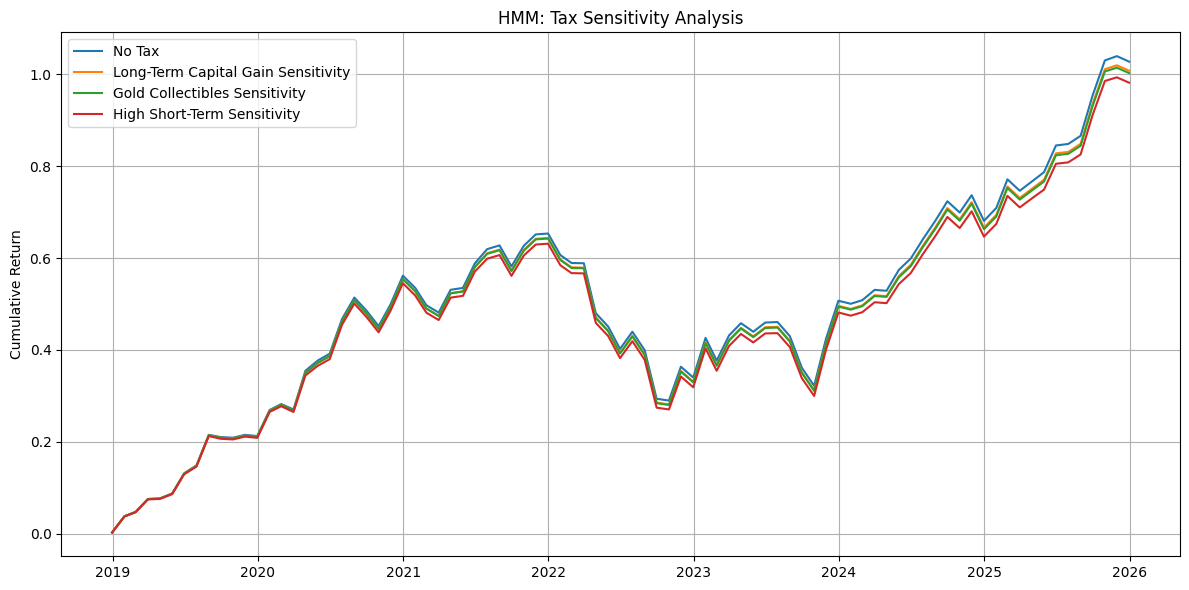

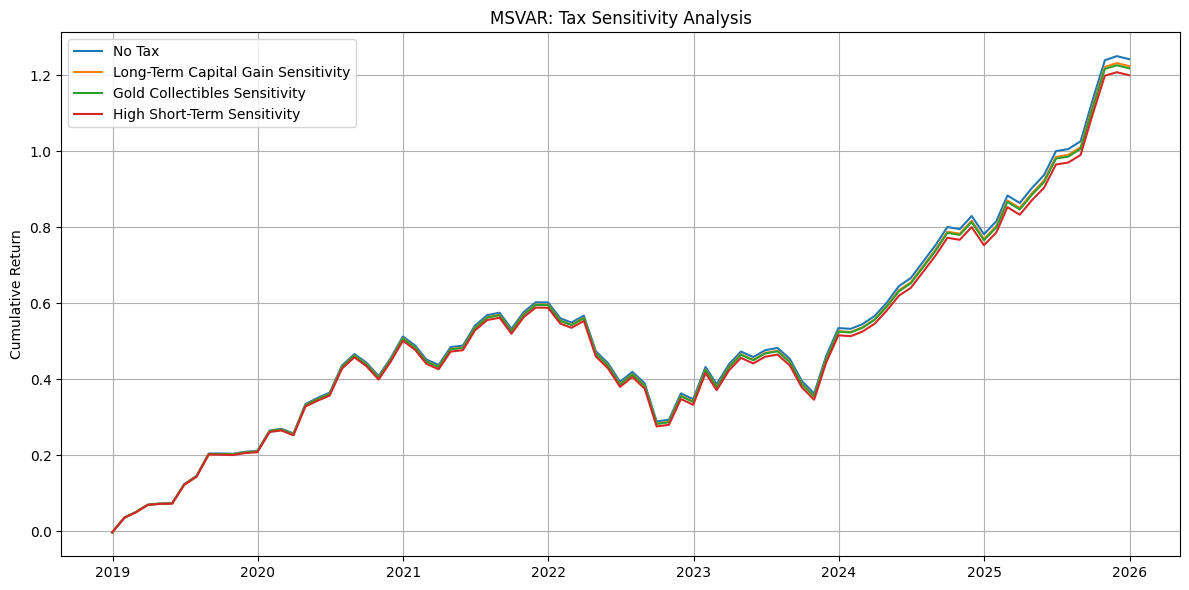

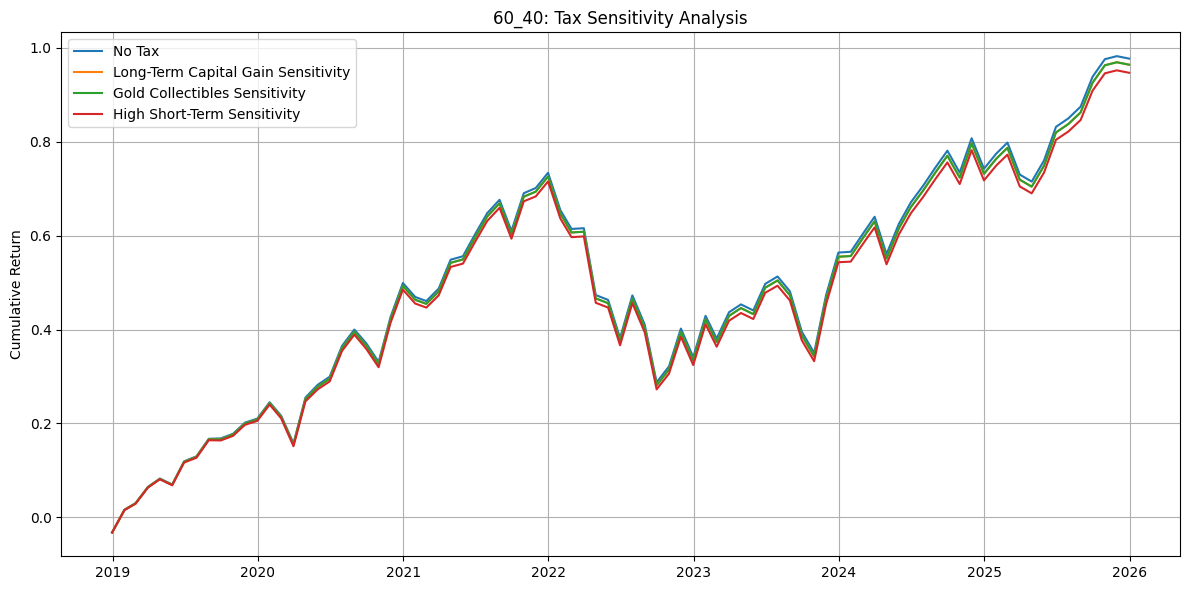

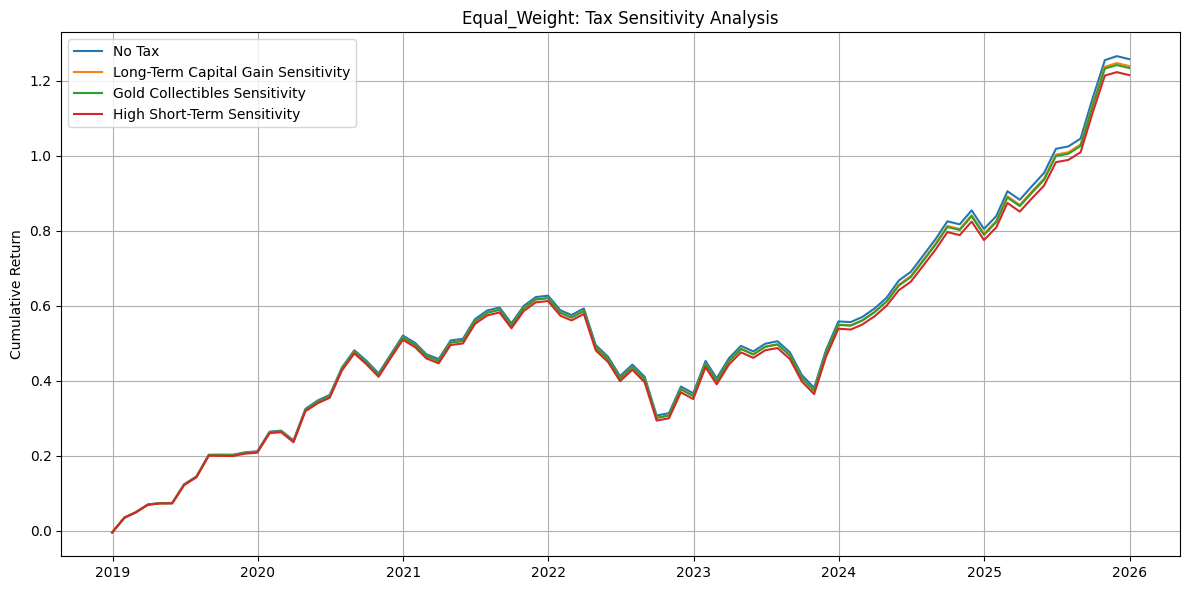

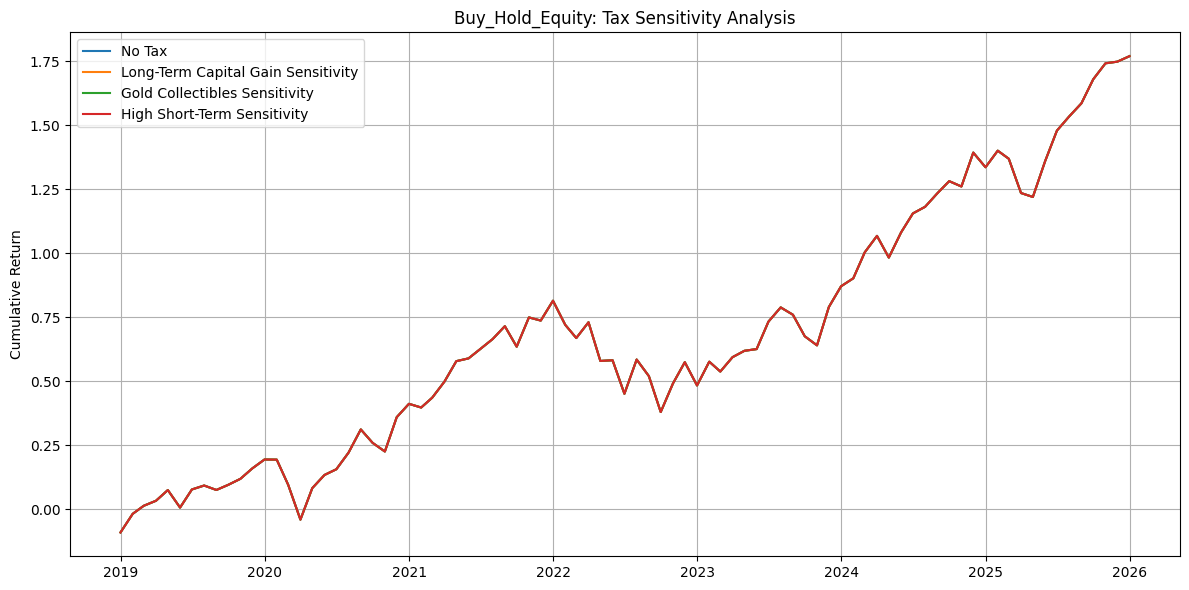

In [17]:
for strategy_name, returns_df in tax_results.items():
    cumulative = (1 + returns_df).cumprod() - 1

    plt.figure(figsize=(12, 6))
    for col in cumulative.columns:
        plt.plot(cumulative.index, cumulative[col], label=col)
    plt.title(f"{strategy_name}: Tax Sensitivity Analysis")
    plt.ylabel("Cumulative Return")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    output_path = OUTPUT_FIGURES_DIR / f"{strategy_name.lower()}_tax_sensitivity.png"
    plt.savefig(output_path, dpi=300)
    plt.show()

## Appendix A: MVO and Bayes-Stein Tangency Portfolio Comparison

This section reproduces the appendix comparison between the main GMV allocation rule, the raw tangency portfolio using sample means, and the Bayes-Stein tangency portfolio using shrunk means.

The output tables are used for Appendix A in the final report.

In [18]:
from sklearn.covariance import LedoitWolf
from src.portfolio import bayes_stein_tangency_portfolio

APPENDIX_SIGNAL_START_DATES = {
    "HMM": pd.Timestamp("2018-10-31"),
    "MSVAR": pd.Timestamp("2018-11-30"),
}

MVO_TARGET_WEIGHT_FILES = {
    "HMM": OUTPUT_TABLES_DIR / "hmm_mvo_target_weights.csv",
    "MSVAR": OUTPUT_TABLES_DIR / "msvar_mvo_target_weights.csv",
}

MVO_MONTHLY_RETURN_FILES = {
    "HMM": OUTPUT_TABLES_DIR / "hmm_mvo_monthly_returns_with_costs.csv",
    "MSVAR": OUTPUT_TABLES_DIR / "msvar_mvo_monthly_returns_with_costs.csv",
}


def build_bayes_stein_target_weights(model_name, base_target_weights):
    """
    Build Bayes-Stein tangency target weights using the model's regime labels.

    The regime labels come from the existing GMV target-weight file. For each
    regime, we estimate sample means and Ledoit-Wolf covariance matrices using
    training-period market returns, shrink the sample means toward the GMV-implied
    flat forecast, and solve a long-only tangency portfolio.
    """
    training_data = asset_returns.join(
        base_target_weights["regime_label"].rename("regime_label"),
        how="inner",
    ).loc[: "2018-10-31"]

    bs_weights_by_regime = {}
    bs_diagnostics = []

    for regime in sorted(training_data["regime_label"].dropna().unique()):
        regime_returns = training_data.loc[
            training_data["regime_label"] == regime,
            ASSET_COLS,
        ]

        mu = regime_returns.mean().values
        sigma = LedoitWolf().fit(regime_returns.values).covariance_

        result, shrunk_mu, shrinkage, target_mean = bayes_stein_tangency_portfolio(
            mu=mu,
            sigma=sigma,
            n_obs=len(regime_returns),
            asset_names=ASSET_COLS,
            rf=0.0,
            long_only=True,
            regime=regime,
        )

        bs_weights_by_regime[regime] = result.weights

        bs_diagnostics.append({
            "Model": model_name,
            "Objective": "MVO-BS",
            "Regime": regime,
            "N Obs": len(regime_returns),
            "Shrinkage": shrinkage,
            "Target Mean Monthly": target_mean,
            "Equity": result.weights[0],
            "Bonds": result.weights[1],
            "Gold": result.weights[2],
        })

    rows = []

    for date, row in base_target_weights.iterrows():
        regime = row["regime_label"]
        weights = bs_weights_by_regime[regime]

        rows.append({
            "Date": date,
            "regime_label": regime,
            "index_fund": weights[0],
            "treasury_fund": weights[1],
            "gold_fund": weights[2],
        })

    bs_target_weights = pd.DataFrame(rows).set_index("Date").sort_index()
    bs_diagnostics = pd.DataFrame(bs_diagnostics)

    return bs_target_weights, bs_diagnostics


def target_weight_summary(weights, model_name, objective_name):
    """
    Convert a full target-weight file into one row per regime for appendix Table 8.
    """
    rows = []

    for regime in sorted(weights["regime_label"].dropna().unique()):
        regime_weights = weights.loc[weights["regime_label"] == regime, ASSET_COLS].iloc[0]

        rows.append({
            "Model": model_name,
            "Objective": objective_name,
            "Regime": regime,
            "Equity": regime_weights["index_fund"],
            "Bonds": regime_weights["treasury_fund"],
            "Gold": regime_weights["gold_fund"],
        })

    return pd.DataFrame(rows)


appendix_weight_blocks = []
appendix_results = {
    "HMM — GMV": cost_results["HMM"],
    "MSVAR — GMV": cost_results["MSVAR"],
    "Equal Weight": cost_results["Equal_Weight"],
    "60/40": cost_results["60_40"],
}

bs_diagnostic_blocks = []

for model_name in ["HMM", "MSVAR"]:
    # Existing GMV weights
    gmv_weights = model_weights[model_name]

    # Existing raw MVO weights from model notebooks
    raw_mvo_weights = load_target_weights(MVO_TARGET_WEIGHT_FILES[model_name])
    validate_target_weights(raw_mvo_weights)

    # New Bayes-Stein MVO weights
    bs_weights, bs_diagnostics = build_bayes_stein_target_weights(
        model_name=model_name,
        base_target_weights=gmv_weights,
    )

    validate_target_weights(bs_weights)
    bs_diagnostic_blocks.append(bs_diagnostics)

    # Save Bayes-Stein target weights in upstream-compatible format
    bs_output = bs_weights.rename(columns={
        "regime_label": "Regime",
        "index_fund": "Equity",
        "treasury_fund": "Bonds",
        "gold_fund": "Gold",
    })

    bs_output.to_csv(
        OUTPUT_TABLES_DIR / f"{model_name.lower()}_mvo_bs_target_weights.csv"
    )

    # Backtest Bayes-Stein weights
    bs_test_weights = bs_weights.loc[
        bs_weights.index >= APPENDIX_SIGNAL_START_DATES[model_name]
    ].copy()

    bs_result_raw = backtest_with_transaction_costs(
        target_weights=bs_test_weights,
        asset_returns=asset_returns,
        transaction_cost_bps=TRANSACTION_COST_BPS,
        apply_signal_lag=True,
        include_initial_trade_cost=False,
    )

    bs_result = bs_result_raw.loc[common_result_index].copy()

    first_date = bs_result.index[0]
    bs_result.loc[first_date, "trade_notional"] = 0.0
    bs_result.loc[first_date, "one_way_turnover"] = 0.0
    bs_result.loc[first_date, "transaction_cost"] = 0.0
    bs_result.loc[first_date, "net_return_after_costs"] = bs_result.loc[first_date, "gross_return"]

    bs_result.to_csv(
        OUTPUT_TABLES_DIR / f"{model_name.lower()}_mvo_bs_monthly_returns_with_costs.csv"
    )

    # Load raw MVO backtest and align it to the same common test window
    raw_mvo_result = pd.read_csv(
        MVO_MONTHLY_RETURN_FILES[model_name],
        parse_dates=["Date"],
    ).set_index("Date").sort_index()

    raw_mvo_result = raw_mvo_result.loc[common_result_index].copy()

    appendix_results[f"{model_name} — MVO"] = raw_mvo_result
    appendix_results[f"{model_name} — MVO-BS"] = bs_result

    # Table 8-style weight summary
    appendix_weight_blocks.append(
        target_weight_summary(gmv_weights, model_name, "GMV")
    )
    appendix_weight_blocks.append(
        target_weight_summary(raw_mvo_weights, model_name, "MVO")
    )
    appendix_weight_blocks.append(
        target_weight_summary(bs_weights, model_name, "MVO-BS")
    )


appendix_regime_weights = pd.concat(
    appendix_weight_blocks,
    ignore_index=True,
)

objective_order = {"GMV": 0, "MVO": 1, "MVO-BS": 2}

appendix_regime_weights["Objective Order"] = appendix_regime_weights["Objective"].map(objective_order)

appendix_regime_weights = appendix_regime_weights.sort_values(
    ["Model", "Objective Order", "Regime"]
).drop(columns=["Objective Order"])

appendix_regime_weights.to_csv(
    OUTPUT_TABLES_DIR / "appendix_mvo_regime_weights.csv",
    index=False,
)

appendix_bayes_stein_diagnostics = pd.concat(
    bs_diagnostic_blocks,
    ignore_index=True,
)

appendix_bayes_stein_diagnostics.to_csv(
    OUTPUT_TABLES_DIR / "appendix_bayes_stein_diagnostics.csv",
    index=False,
)

# Table 9-style performance summary
benchmark_reference = cost_results["60_40"]["net_return_after_costs"]

appendix_performance = {}

appendix_order = [
    "HMM — GMV",
    "HMM — MVO",
    "HMM — MVO-BS",
    "MSVAR — GMV",
    "MSVAR — MVO",
    "MSVAR — MVO-BS",
    "Equal Weight",
    "60/40",
]

for strategy_name in appendix_order:
    result = appendix_results[strategy_name]
    returns = result["net_return_after_costs"]

    summary = summarize_performance(
        returns,
        benchmark_returns=None if strategy_name == "60/40" else benchmark_reference,
        risk_free_rate=ANNUAL_RISK_FREE_RATE,
    )

    summary["Cumulative Return"] = returns.add(1.0).prod() - 1.0

    appendix_performance[strategy_name] = summary

appendix_mvo_performance_comparison = pd.DataFrame(appendix_performance).T

appendix_metric_order = [
    "Annualized Return",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Sortino Ratio",
    "Max Drawdown",
    "Cumulative Return",
    "Information Ratio vs 60/40",
]

appendix_mvo_performance_comparison = appendix_mvo_performance_comparison[
    [metric for metric in appendix_metric_order if metric in appendix_mvo_performance_comparison.columns]
]

appendix_mvo_performance_comparison.to_csv(
    OUTPUT_TABLES_DIR / "appendix_mvo_performance_comparison.csv"
)

display(appendix_regime_weights)
display(appendix_bayes_stein_diagnostics)
display(appendix_mvo_performance_comparison)

,Model,Objective,Regime,Equity,Bonds,Gold
0,HMM,GMV,0.0,3.044269e-01,0.448602,0.246971
1,HMM,GMV,1.0,3.147557e-01,0.330648,0.354596
2,HMM,MVO,0.0,4.001148e-01,0.470091,0.129794
3,HMM,MVO,1.0,9.242449e-12,0.691862,0.308138
4,HMM,MVO-BS,0.0,3.436854e-01,0.457151,0.199164
5,HMM,MVO-BS,1.0,1.050459e-01,0.521494,0.373460
6,MSVAR,GMV,0.0,3.176793e-01,0.328343,0.353978
7,MSVAR,GMV,1.0,2.925551e-01,0.424206,0.283239
8,MSVAR,MVO,0.0,2.329108e-09,0.686784,0.313216
9,MSVAR,MVO,1.0,3.740767e-01,0.463031,0.162893


,Model,Objective,Regime,N Obs,Shrinkage,Target Mean Monthly,Equity,Bonds,Gold
0,HMM,MVO-BS,0,323,0.552979,0.006980,0.343685,0.457151,0.199164
1,HMM,MVO-BS,1,22,0.695085,0.005933,0.105046,0.521494,0.373460
2,MSVAR,MVO-BS,0,334,0.612882,0.006682,0.324114,0.439236,0.236651
3,MSVAR,MVO-BS,1,10,0.655510,0.011609,0.195742,0.460686,0.343573


,Annualized Return,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Cumulative Return,Information Ratio vs 60/40
HMM — GMV,0.104933,0.101296,0.776086,1.250101,-0.219934,1.027504,0.012543
HMM — MVO,0.065893,0.106259,0.403976,0.645376,-0.253540,0.571462,-0.606815
HMM — MVO-BS,0.083080,0.101670,0.575769,0.919893,-0.235788,0.760003,-0.329895
MSVAR — GMV,0.120785,0.095278,0.969804,1.563318,-0.195660,1.242767,0.226197
MSVAR — MVO,0.089186,0.114401,0.572504,1.189557,-0.275702,0.831502,-0.132306
MSVAR — MVO-BS,0.096408,0.099184,0.711867,1.109138,-0.218375,0.919274,-0.118778
Equal Weight,0.121807,0.096629,0.967087,1.589712,-0.196336,1.257287,0.260099
60/40,0.101011,0.126502,0.615777,1.037141,-0.257392,0.977082,NaN
